<a href="https://colab.research.google.com/github/karanbhatt1/DeepLearningModels/blob/main/catsanddogclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from google.colab.patches import cv2_imshow
import os
import pickle

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(377, 500, 3)


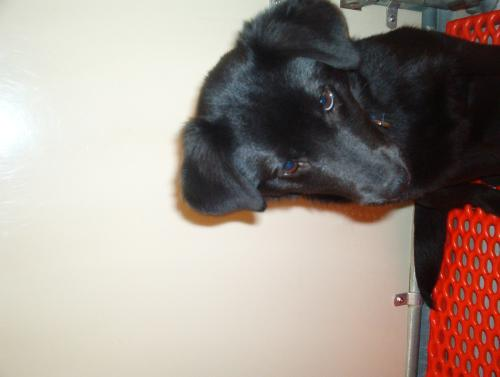

In [25]:
import cv2
img = cv.imread('/content/drive/MyDrive/Datasets/PetImages/Dog/12498.jpg')
print(img.shape)
cv2_imshow(img)
gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

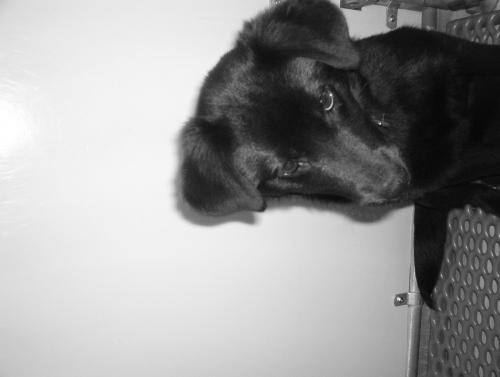

(377, 500)


In [26]:
cv2_imshow(gray_img)
print(gray_img.shape)


In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [28]:
i_d_g = ImageDataGenerator(
    #Normalization: Rescaling the values of matries from 1-255 to 0-1 so model can be trained fast and efficiently.
    rescale = 1./255,
    validation_split = 0.2
)

# Using Image Data Generator for directly loading from directory:
- flow_from_directory()

In [29]:
path  = '/content/drive/MyDrive/Datasets/PetImages'
train_data_flow = i_d_g.flow_from_directory(
    path,
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'binary',
    subset='training'
)

val_data = i_d_g.flow_from_directory(
    path,
    target_size=(224, 224),
    batch_size=64,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


# Now using Tensorflow sequential model to build a custom CNN model:

In [30]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

In [31]:
# data_augment = Sequential(
#     [
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.1),
#         layers.RandomZoom(0.2),
#         layers.RandomContrast(0.2),
#     ]
# )

In [32]:
model1 = Sequential(
    [
        keras.Input(shape = (224,224,3)),
        layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(units=64,activation='relu'),
        layers.Dense(units=1,activation='sigmoid')
    ]
)

In [33]:
from tensorflow.keras.optimizers import Adam

In [34]:
model1.compile(optimizer='adam',
              loss="binary_crossentropy",
              metrics=["accuracy"])

NameError: name 'model' is not defined

#How These Parameters are calculates :
- Let's understand : first notice the input size (224,224,3)
- then first conv2d layer has 32 filters of size 3*3 and we have 3 channels.
- From each channel(3) the kernal moves with dimensions 3*3 which is equal to 9.
- Then 9*3 = 27 and 27 * 32 = 864 and we have 32 biases so total comes out to be 864 + 32 = 896 parameter.
- **This means parameters are weights and biases**

# What does Max_pooling Do:
- It take a highest value of pixel from each patch of specified size here is (2,2)

-So, then 222/2,222/2 => 111,111,32 we get

In [ ]:
model1.summary()

In [ ]:
history1 = model1.fit(train_data_flow , validation_data=val_data, epochs = 5)

In [ ]:
!nvidia-smi

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

# Model 2
- Applying MAX Pooling and regularization to minimize the overfitting issue.
- The last model gave the accuracy of 90.25% and validation accuracy of 81.25%.
- There was in total 5 epochs so in this model there will be total of 10 epochs.

## Applying MaxPolling(2,2)
-> after each Conv2d layer we just take the maxpixel value from 2*2 matrix in images for each layer.  
-> Applying regularization layers.drop(0.2)

In [35]:
from tensorflow.keras.optimizers import Adam

In [36]:
def model2():
  model = Sequential(
      [
        keras.Input(shape = (224,224,3)),

        layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(units=64,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(units=1,activation='sigmoid')
      ]
  )
  return model

In [37]:
model_2 = model2()

In [38]:
model_2.compile(optimizer='adam',
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [39]:
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,169 (21.48 MB)

 Trainable params: 5,631,169 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history_2 = model_2.fit(train_data_flow , validation_data=val_data, epochs = 10)

Epoch 1/10
163/313 ━━━━━━━━━━━━━━━━━━━━ 1:13:55 30s/step - accuracy: 0.5062 - loss: 0.9222

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


313/313 ━━━━━━━━━━━━━━━━━━━━ 11680s 37s/step - accuracy: 0.5001 - loss: 0.7211 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 323ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 327ms/step - accuracy: 0.4996 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.5055 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.4979 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 314ms/step - accuracy: 0.4992 - loss: 0.6932

In [41]:
path_model = "/content/drive/MyDrive/Models/custom_cnn_regularized.keras"
model_2.save(path_model)

In [42]:
path_history_2 = '/content/drive/MyDrive/Models/custom_cnn_baseline_history.csv'
history_df_2 = pd.DataFrame(history_2.history)
history_df_2.to_csv("custom_cnn_baseline_history.csv", index=False)